# hmfast + Cobaya — **F** constraints (GetDist, signal-only)

Styling matches `/scratch/scratch-lxu/tsz_cnc_paper_plots/plot_combine_signalonly.ipynb` (serif, `usetex`, GetDist).

The combined parameter **F** (paper-style) is

$$F = \sigma_8\, [\Omega_m\,(1/B)]^{0.40}\, (H_0/100)^{-0.21}$$

with **B** the GNFW hydrostatic bias. The tutorial YAML **samples B** (along with LCDM parameters); **F** is added here as a derived quantity from the chain. If a chain has no **B** column (older runs with fixed B), the notebook falls back to **B = 1.41** when building **F**.

Plots: **(1)** 1D marginal for **F**; **(2)** triangle for **F**, **B**, and **σ₈** so the **F** constraint is visible together with the varied nuisance **B** and derived **σ₈**.

Edit **`CHAIN_ROOT`** if your Cobaya output prefix differs.

In [38]:
import os
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

from getdist.mcsamples import loadMCSamples
from getdist import plots

mpl.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 25,
        "axes.labelsize": 25,
        "axes.titlesize": 25,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 25,
        "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{type1cm}\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}",
    }
)
# mpl.rcParams["text.usetex"] = False  # if no LaTeX

In [39]:
TUTORIAL_DIR = Path("/home/lxu/scratch/compute_packages/hmfast/tutorial").resolve()
CHAIN_ROOT = TUTORIAL_DIR / "chains" / "tutorial_hmfast_tszhmfast_fullsky" / "chains"

chain_file = CHAIN_ROOT.parent / "chains.1.txt"
assert chain_file.exists(), f"Missing {chain_file}"

BURN_FRACTION = 0.35

samples = loadMCSamples(
    str(CHAIN_ROOT),
    settings={"ignore_rows": BURN_FRACTION},
)
print("Samples:", samples.numrows)

Samples: 3342


In [ ]:
import sys

HMFAST_SRC = TUTORIAL_DIR.parent / "src"
if str(HMFAST_SRC) not in sys.path:
    sys.path.insert(0, str(HMFAST_SRC))

from hmfast.cosmology import Cosmology

p = samples.getParams()
N = len(p.H0)
# Fallback when chains omit B (fixed-B runs); sampled chains carry column B.
_B_FID = 1.41
sigma8_vals = np.empty(N, dtype=np.float64)
_seed = Cosmology(emulator_set="lcdm:v1")
TAU = 0.0544

for i in range(N):
    c = _seed.update(
        H0=float(p.H0[i]),
        omega_cdm=float(p.omega_cdm[i]),
        omega_b=float(p.omega_b[i]),
        ln1e10A_s=float(p.ln10_10A_s[i]),
        n_s=float(p.n_s[i]),
        tau_reio=TAU,
    )
    sigma8_vals[i] = float(np.asarray(c.sigma8(0.0)))

samples.addDerived(sigma8_vals, name="sigma8", label=r"\sigma_8")
p = samples.getParams()

# Same combination as tsz_cnc_paper_plots; use chain B if present, else fixed fiducial.
B_arr = np.asarray(p.B) if hasattr(p, "B") else np.full(N, _B_FID)
one_minus_b = 1.0 / B_arr
F_vals = (
    p.sigma8
    * (p.Omega_m * one_minus_b) ** 0.40
    * (p.H0 / 100.0) ** (-0.21)
)
samples.addDerived(F_vals, name="F", label=r"F")

print(
    "Derived F mean =",
    float(np.mean(F_vals)),
    "| B:",
    "sampled" if hasattr(samples.getParams(), "B") else f"fixed at {_B_FID}",
)

# --- Truth reference (synthetic / prior centres; tune as needed) ---
truth = {
    "H0": 67.66,
    "ln10_10A_s": 2.9718,
    "n_s": 0.9665,
    "omega_b": 0.02242,
    "omega_cdm": 0.1193,
    "Omega_m": (0.0),
    "tau_reio": 0.0544,
    "B": 1.41,
}

_ct = Cosmology(emulator_set="lcdm:v1").update(
    H0=truth["H0"],
    omega_cdm=truth["omega_cdm"],
    omega_b=truth["omega_b"],
    ln1e10A_s=truth["ln10_10A_s"],
    n_s=truth["n_s"],
    tau_reio=TAU,
)
truth["sigma8"] = float(np.asarray(_ct.sigma8(0.0)))
truth["F"] = (
    truth["sigma8"]
    * (truth["Omega_m"] / truth["B"]) ** 0.40
    * (truth["H0"] / 100.0) ** (-0.21)
)

label = r"hmfast + Cobaya (full-sky $D_\ell$, signal only)"
color = "royalblue"

Derived F mean = 0.47585034449513175 | B: sampled


Saved /scratch/scratch-lxu/compute_packages/hmfast/tutorial/hmfast_cobaya_F_signal_only.png


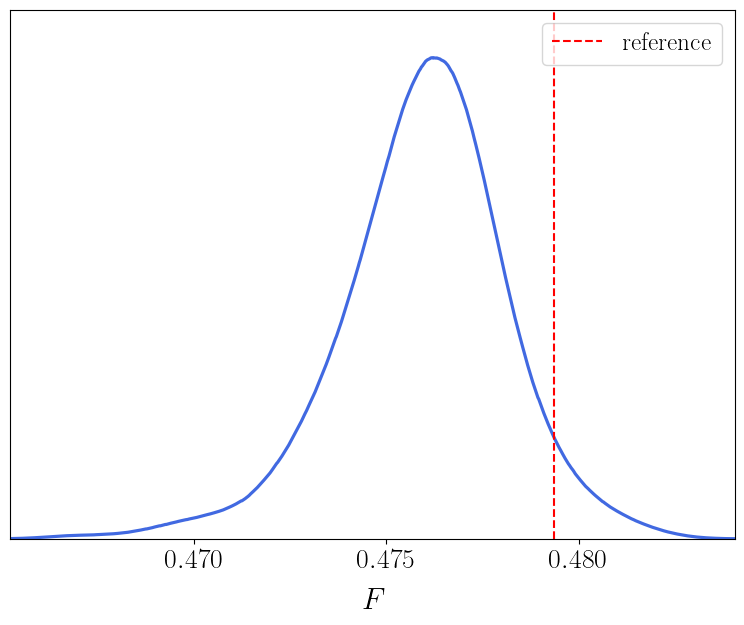

In [41]:
# --- 1D marginal for F ---
g = plots.get_single_plotter(width_inch=8, ratio=0.85)
g.settings.lab_fontsize = 22
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 22
g.settings.alpha_filled_add = 0.5

g.plot_1d(
    samples,
    "F",
    filled=True,
    legend_labels=[label],
    colors=[color],
)

# Newer GetDist: g.subplots is an ndarray of Axes, not a single Axes.
_sub = g.subplots
ax = _sub.flat[0] if isinstance(_sub, np.ndarray) else _sub
ax.axvline(truth["F"], color="red", ls="--", lw=1.5, label="reference")
ax.legend(loc="upper right", fontsize=18)

out_png = TUTORIAL_DIR / "hmfast_cobaya_F_signal_only.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print("Saved", out_png)
plt.show()

Saved /scratch/scratch-lxu/compute_packages/hmfast/tutorial/hmfast_cobaya_triangle_F_B_sigma8.png


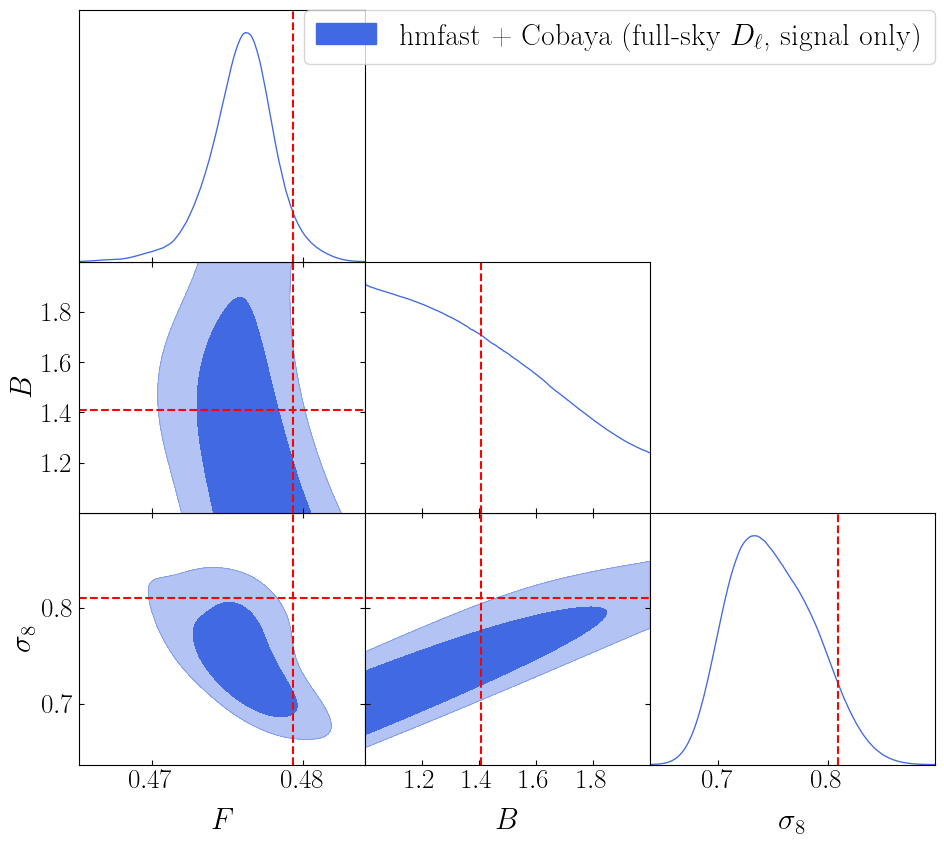

In [42]:
# --- Triangle: F vs sampled B vs σ₈ (shows F constraint with nuisance B free) ---
triangle_params = ["F", "B", "sigma8"]
truth_triangle = {k: truth[k] for k in triangle_params}

g_tri = plots.get_subplot_plotter(width_inch=10, subplot_size_ratio=0.9)
g_tri.settings.lab_fontsize = 22
g_tri.settings.axes_fontsize = 20
g_tri.settings.legend_fontsize = 22
g_tri.settings.alpha_filled_add = 0.5

g_tri.triangle_plot(
    [samples],
    triangle_params,
    filled=True,
    legend_labels=[label],
    contour_colors=[color],
    markers=truth_triangle,
    marker_args={"color": "red", "ls": "--", "lw": 1.5},
)

out_triangle = TUTORIAL_DIR / "hmfast_cobaya_triangle_F_B_sigma8.png"
plt.savefig(out_triangle, dpi=300, bbox_inches="tight")
print("Saved", out_triangle)
plt.show()